In [1]:
from blackjack import Blackjack, Player, Trainer, Qtable, Evaluator
import os
import sys
from contextlib import redirect_stdout
import random
import numpy as np
import os

In [3]:
def random_hit(points, hand, dealer_card, true_count):
    rand = random.random()
    if rand >= 0.5:
        return 'hit'
    if rand < 0.5:
        return 'stand'

def basic_dec(points, hand, dealer_card, true_count):
    if points >= 16:
        return 'stand'
    elif points < 16:
        return 'hit'
def smarter_dec(points, hand, dealer_card, true_count):
    dealer_vals = {
        'Ace': 11,
        'K': 10,
        'Q': 10,
        'J': 10
    }

    dealer_points = dealer_vals.get(dealer_card, dealer_card)

    soft = 'Ace' in hand and points <= 21 and points - 11 + 1 <= 10

    if soft:
        if points <= 17:
            return 'hit'
        elif points == 18:
            if dealer_points >= 9:
                return 'hit'
            return 'stand'
        else:
            return 'stand'

    if points <= 11:
        return 'hit'
    elif 12 <= points <= 16:
        if dealer_points >= 7:
            return 'hit'
        else:
            return 'stand'
    else:
        return 'stand'

In [ ]:
eps_0 = 1
eps_f = 0.02
eps_decay = 0.999999
episodes = 7500000
hypers = [eps_0, eps_f, eps_decay, episodes]
trainer = Trainer(hyperparams=hypers)
trainer.train()
q_table = trainer.qtable.get_table()
trainer.qtable.save_table()
#q_table = trainer.qtable.load_table() # to get saved q table


BLACKJACK PLAYER SUMMARY ----------------------------------------------------------


On average, the model won -0.030805
The model played 100000 rounds 10 times
The average final ending amount for the model was 114842.57249999992
The model surrendered 17684 times
The model double_downed 17407 times
The model split 7531 times
The model insured 0 times


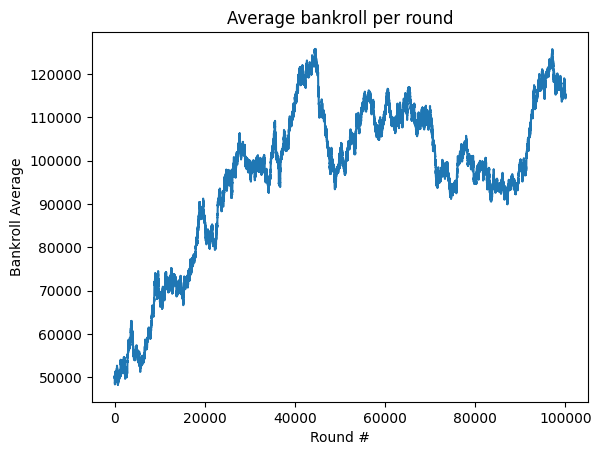

In [3]:
qtable = Qtable()
q_table = qtable.load_table(file_name='saved_qtable.pkl') # to get saved q table
#q_table = trainer.qtable.get_table()
evaluator = Evaluator(qtable=q_table, rounds=100000, epochs=10)
evaluator.eval()
evaluator.get_data()